# Run Model Notebook (Clean)

This notebook runs a single-country simulation end-to-end and provides a compact analysis workflow.

## How To Use
1. Update parameters in **Inputs**.
2. Run all cells from top to bottom.
3. Review validation summaries and plots.

## Prerequisites
- Environment with project dependencies installed.
- Data available at `data/hfcs/raw` (or set `RAW_DATA_PATH`).


## Sections
- Setup
- Inputs
- Data Preparation
- Country Configuration
- Run Simulation
- Outputs And Plots
- National Accounts Comparison
- Optional Scenario Comparison


In [1]:
# Setup
%load_ext autoreload
%autoreload 2

import logging
import os
import random
from pathlib import Path
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import Config
from macro_data import DataWrapper
from macro_data.configuration import DataConfiguration, split_country_configs
from macro_data.configuration_utils import default_data_configuration, read_country_conf
from macromodel.configurations import CountryConfiguration, SimulationConfiguration
from macromodel.simulation import Simulation
from macromodel.util.loader import Loader
from src.helpers import align_country_configuration_to_data, unpack_cell
from src.visual_helpers import build_macro_output_df, plot_output

logging.getLogger().setLevel(logging.ERROR)


In [2]:
# Inputs
seed = 24 # 32
t_max = 50

# Optional overrides (None means use Config/default env values)
seed_override = seed
country_override = None
raw_data_path_override = None
output_dir_override = None
t_max_override = t_max

cfg = Config().from_env()
if country_override is not None:
    cfg.country_iso3 = country_override
if t_max_override is not None:
    cfg.t_max = t_max_override
if seed_override is not None:
    cfg.seed = seed

random.seed(cfg.seed)

raw_data_path = Path(raw_data_path_override) if raw_data_path_override else (cfg.raw_data_path or Path('data/hfcs/raw'))
output_dir = Path(output_dir_override) if output_dir_override else (cfg.output_path or Path('data/output'))
output_dir.mkdir(parents=True, exist_ok=True)

data_pkl_path = output_dir / 'data.pkl'
model_h5_path = output_dir / 'multi_country_simulation.h5'

print({'seed': cfg.seed, 'country': cfg.country_iso3, 't_max': cfg.t_max, 'raw_data_path': str(raw_data_path), 'output_dir': str(output_dir)})


{'seed': 24, 'country': 'FRA', 't_max': 50, 'raw_data_path': '/Users/andone/Documents/python_projects/macro-main/run_model/data/raw_data', 'output_dir': '/Users/andone/Documents/python_projects/macro-main/run_model/data/output_data'}


In [3]:
# Data Preparation
assert raw_data_path.exists(), f'Raw data path not found: {raw_data_path}'

# Load data configuration
with open(f"{cfg.config_dir}/data_config_FRA.yaml", "r") as f:
    data_config = yaml.safe_load(f)
data_config["country_configs"] = split_country_configs(data_config["country_configs"])
data_config = DataConfiguration(**data_config)

#  Create country data
creator = DataWrapper.from_config(
    configuration=data_config,
    raw_data_path=raw_data_path,
    single_hfcs_survey=False,
)
creator.save(str(data_pkl_path))
data = DataWrapper.init_from_pickle(str(data_pkl_path))

synthetic_country = creator.synthetic_countries[cfg.country_iso3]
na = synthetic_country.exogenous_data.national_accounts

In [4]:
# Load country configuration
with open(f"{cfg.config_dir}/country_config_FRA.yaml", "r") as f:
    country_config_dict = yaml.safe_load(f)
country_cfg = CountryConfiguration(**country_config_dict[cfg.country_iso3])
country_cfg = align_country_configuration_to_data(country_cfg, n_industries=data.n_industries)
country_configurations = {cfg.country_iso3: country_cfg}

# Modify loaded country config
country_cfg = country_configurations[cfg.country_iso3]
country_cfg.firms.functions.productivity_growth.name = 'SimpleTFPGrowth'  #'NoOpTFPGrowth'
country_cfg.labour_market.functions.clearing.name = 'PolednaLabourMarketClearer'
country_cfg.central_bank.functions.policy_rate.name = 'PolednaPolicyRate'
country_cfg.government_entities.functions.consumption.name = 'AutoregressiveGovernmentConsumptionSetter'
country_cfg.central_government.functions.social_benefits.name = 'DefaultSocialBenefitsARXSetter'

# "AutoregressiveGovernmentConsumptionSetter",
# "ConstantGrowthGovernmentConsumptionSetter",
# "ExogenousGovernmentConsumptionSetter"

# # Labour market and policy
# country_cfg.labour_market.functions.clearing.parameters['hiring_speed'] = 0.9
# country_cfg.labour_market.functions.clearing.parameters['firing_speed'] = 0.9
# country_cfg.labour_market.functions.clearing.parameters['random_firing_probability'] = 0.01
# country_cfg.labour_market.functions.clearing.parameters['individuals_quitting'] = True
# country_cfg.labour_market.functions.clearing.parameters['individuals_quitting_temperature'] = 0.3
# country_cfg.labour_market.functions.clearing.parameters['compare_with_normalised_inputs'] = True
# country_cfg.labour_market.functions.clearing.parameters['firing_cost_fraction'] = 0.05
# country_cfg.labour_market.functions.clearing.parameters['hiring_cost_fraction'] = 0.02

print('Configuration summary')
print({'productivity_growth': country_cfg.firms.functions.productivity_growth.name,
       'labour_market_clearer': country_cfg.labour_market.functions.clearing.name,
       'policy_rate_rule': country_cfg.central_bank.functions.policy_rate.name})


Configuration summary
{'productivity_growth': 'SimpleTFPGrowth', 'labour_market_clearer': 'PolednaLabourMarketClearer', 'policy_rate_rule': 'PolednaPolicyRate'}


In [5]:
seed = cfg.seed
seed = 59
# Run single Simulation
configuration = SimulationConfiguration(
    country_configurations=country_configurations,
    t_max=cfg.t_max,
    seed=seed,
)

model = Simulation.from_datawrapper(
    datawrapper=data,
    simulation_configuration=configuration,
)

import warnings
warnings.simplefilter("always", RuntimeWarning)

model.run()
model.save(save_dir=output_dir, file_name=model_h5_path.name)

print(f'Simulation complete. Output saved to: {model_h5_path}')


# Outputs And Plots
plot_columns = [
    'total consumption to gdp', 'investment to gdp', 'net exports to gdp',
    'debt to gdp', 'fiscal revenue to gdp', 'fiscal expenditure to gdp', 'deficit to gdp',
    'household consumption to gdp', 'government consumption to gdp', 'gdp',
    'gdp growth', 'unemployment rate', 'central bank policy rate', 
    'wages', 'profits', 'cpi', 'ppi',
    'taxes paid on production', 'taxes on products', 'government consumption',
    # 'Imports', 'Exports',
    'consumption expansion loan debt', 'mortgage debt',
]

# df_base = build_macro_output_df(cfg, model, country_code=cfg.country_iso3)
df_base = build_macro_output_df(model, country_code=cfg.country_iso3)
n_rows = 6
n_cols = 4

plot_output(
    df=df_base[plot_columns],
    no_rows=n_rows,
    no_cols=n_cols,
    country_code=cfg.country_iso3,
    line_color="#1f77b4",
    base_height=200,
    base_width=400,
)

# df_base.to_csv(cfg.output_path / "macro_output.csv")

Simulation complete. Output saved to: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/multi_country_simulation.h5


In [8]:
plot_output(
    df=df_base[
        ['unemployment_benefits_by_individual', 'total_other_benefits', 'government consumption',
         'unemp_benefits_to_expenditure', 'other_benefits_to_expenditure', 'gov_consumption_to_expenditure', 
         'unemployment rate', 'gdp growth', 'debt to gdp']
         ],
    no_rows=3,
    no_cols=3,
    country_code=cfg.country_iso3,
    line_color="#1f77b4",
    base_height=200,
    base_width=400,
)

In [ ]:
from src.helpers import fit_social_benefits_arx_diagnostics
from macro_data.readers.default_readers import DataReaders
from macro_data.readers import AGGREGATED_INDUSTRIES, ALL_INDUSTRIES

country_names = data_config.countries
industries = AGGREGATED_INDUSTRIES if data_config.aggregate_industries else ALL_INDUSTRIES
scale_dict = {country: data_config.country_configs[country].scale for country in country_names}
proxy_country_dict = {
    country: data_config.country_configs[country].eu_proxy_country
    for country in data_config.countries
    if not country.is_eu_country
}

readers = DataReaders.from_raw_data(
    raw_data_path=cfg.raw_data_path,
    country_names=country_names,
    simulation_year=data_config.year,
    scale_dict=scale_dict,
    industries=industries,
    aggregate_industries=data_config.aggregate_industries,
    prune_date=data_config.prune_date,
    force_single_hfcs_survey=False,
    single_icio_survey=True,
    proxy_country_dict=proxy_country_dict,
    use_disagg_can_2014_reader=data_config.can_disaggregation,
    use_provincial_can_reader=False,
    regions_dict=None,
    allow_missing_emissions=False,
)



In [ ]:
diagnostics = fit_social_benefits_arx_diagnostics(
    readers=readers,
    country_name=country_names[0],
    year=data_config.year,
    year_range=10,
    regression_window=48,
    log_floor=1e-8,
)

diagnostics["unemployment_benefits"]["results"].summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     Delta Log Other Benefits   R-squared:                       0.037
Model:                                  OLS   Adj. R-squared:                 -0.053
Method:                       Least Squares   F-statistic:                    0.4102
Date:                      Tue, 21 Apr 2026   Prob (F-statistic):              0.747
Time:                              17:50:33   Log-Likelihood:                 173.08
No. Observations:                        36   AIC:                            -338.2
Df Residuals:                            32   BIC:                            -331.8
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0091      0.001     15.560      0.000       0.008       0.010
Lagged Inflation       -0.1198      0.113     -1.061      0.297      -0.350       0.110
Unemployment Change     0.0458      0.164      0.279      0.782      -0.288       0.380
GDP Growth              0.0165      0.063      0.264      0.794      -0.111       0.144
==============================================================================
Omnibus:                        5.991   Durbin-Watson:                   0.301
Prob(Omnibus):                  0.050   Jarque-Bera (JB):                2.230
Skew:                           0.219   Prob(JB):                        0.328
Kurtosis:                       1.862   Cond. No.                         484.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
diagnostics["other_benefits"]["results"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     Delta Log Other Benefits   R-squared:                       0.037
Model:                                  OLS   Adj. R-squared:                 -0.053
Method:                       Least Squares   F-statistic:                    0.4102
Date:                      Tue, 21 Apr 2026   Prob (F-statistic):              0.747
Time:                              17:50:42   Log-Likelihood:                 173.08
No. Observations:                        36   AIC:                            -338.2
Df Residuals:                            32   BIC:                            -331.8
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0091      0.001     15.560      0.000       0.008       0.010
Lagged Inflation       -0.1198      0.113     -1.061      0.297      -0.350       0.110
Unemployment Change     0.0458      0.164      0.279      0.782      -0.288       0.380
GDP Growth              0.0165      0.063      0.264      0.794      -0.111       0.144
==============================================================================
Omnibus:                        5.991   Durbin-Watson:                   0.301
Prob(Omnibus):                  0.050   Jarque-Bera (JB):                2.230
Skew:                           0.219   Prob(JB):                        0.328
Kurtosis:                       1.862   Cond. No.                         484.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

                                  OLS Regression Results                                  
Dep. Variable:     Delta Log Other Total Benefits   R-squared:                       0.068
Model:                                        OLS   Adj. R-squared:                 -0.019
Method:                             Least Squares   F-statistic:                    0.7830
Date:                            Tue, 21 Apr 2026   Prob (F-statistic):              0.512
Time:                                    18:05:01   Log-Likelihood:                 173.67
No. Observations:                              36   AIC:                            -339.3
Df Residuals:                                  32   BIC:                            -333.0
Df Model:                                       3                                         
Covariance Type:                        nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---

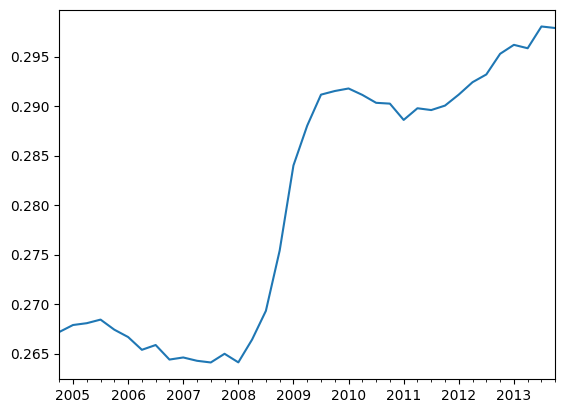

In [ ]:
import numpy as np
import statsmodels.api as sm
from src.helpers import build_social_benefits_reader_df

df_benefits = build_social_benefits_reader_df(
    readers=readers,
    country_name=country_names[0],
    year=data_config.year,
    year_range=10,
)

df_benefits['other_benefits_to_gdp'] = df_benefits['Other Total Benefits'] / df_benefits['GDP']
df_benefits['other_benefits_to_gdp'].plot()

df_reg = df_benefits[
    ["Other Total Benefits", "Real CPI Inflation", "Wage Growth", "Population Growth"]
].copy()

df_reg["Delta Log Other Total Benefits"] = np.log(df_reg["Other Total Benefits"]).diff()
df_reg = df_reg.dropna()

y = df_reg["Delta Log Other Total Benefits"]
X = sm.add_constant(df_reg[["Real CPI Inflation", "Wage Growth", "Population Growth"]], has_constant="add")

results = sm.OLS(y, X).fit()



In [114]:
import numpy as np
import statsmodels.api as sm

df_reg = df_benefits[
    [
        "Other Total Benefits",
        "Real CPI Inflation",
        "Unemployment Change",
        "Wage Growth",
        "GDP Growth",
        "Participation Rate Change",
        "Population Growth",
    ]
].copy()

# Target: quarterly growth in other benefits
df_reg["Delta Log Other Total Benefits"] = np.log(df_reg["Other Total Benefits"]).diff()

# Persistence term
df_reg["Lagged Delta Log Other Total Benefits"] = df_reg["Delta Log Other Total Benefits"].shift(1)

df_reg = df_reg.dropna()

y = df_reg["Delta Log Other Total Benefits"]
X = sm.add_constant(
    df_reg[
        [
            "Lagged Delta Log Other Total Benefits",
            "Real CPI Inflation",
            "Unemployment Change",
            "Wage Growth",
            "GDP Growth",
            "Participation Rate Change",
            "Population Growth",
        ]
    ],
    has_constant="add",
)

results = sm.OLS(y, X).fit()

print(results.summary())


                                  OLS Regression Results                                  
Dep. Variable:     Delta Log Other Total Benefits   R-squared:                       0.850
Model:                                        OLS   Adj. R-squared:                  0.811
Method:                             Least Squares   F-statistic:                     21.82
Date:                            Tue, 21 Apr 2026   Prob (F-statistic):           1.44e-09
Time:                                    18:10:23   Log-Likelihood:                 200.37
No. Observations:                              35   AIC:                            -384.7
Df Residuals:                                  27   BIC:                            -372.3
Df Model:                                       7                                         
Covariance Type:                        nonrobust                                         
                                            coef    std err          t      P>|t|      [0.

In [115]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

df_reg = df_benefits[
    [
        "Other Total Benefits",
        "Real CPI Inflation",
        "Unemployment Change",
        "Participation Rate",
    ]
].copy()

# Target
df_reg["Delta Log Other Total Benefits"] = np.log(df_reg["Other Total Benefits"]).diff()

# Persistence
df_reg["Lagged Delta Log Other Total Benefits"] = df_reg["Delta Log Other Total Benefits"].shift(1)

# Slow-moving demographic / pension-pressure proxy
df_reg["Time Trend"] = np.arange(len(df_reg))

df_reg = df_reg.dropna()

y = df_reg["Delta Log Other Total Benefits"]
X = sm.add_constant(
    df_reg[
        [
            "Lagged Delta Log Other Total Benefits",
            "Real CPI Inflation",
            "Unemployment Change",
            "Participation Rate",
            "Time Trend",
        ]
    ],
    has_constant="add",
)

results = sm.OLS(y, X).fit()

print(results.summary())


                                  OLS Regression Results                                  
Dep. Variable:     Delta Log Other Total Benefits   R-squared:                       0.806
Model:                                        OLS   Adj. R-squared:                  0.773
Method:                             Least Squares   F-statistic:                     24.14
Date:                            Tue, 21 Apr 2026   Prob (F-statistic):           1.60e-09
Time:                                    18:10:38   Log-Likelihood:                 195.92
No. Observations:                              35   AIC:                            -379.8
Df Residuals:                                  29   BIC:                            -370.5
Df Model:                                       5                                         
Covariance Type:                        nonrobust                                         
                                            coef    std err          t      P>|t|      [0.

In [64]:
run_benchmark = True
force_rerun_benchmark = True

if run_benchmark:
    output_dir = cfg.output_path or Path("data/output")
    output_dir.mkdir(parents=True, exist_ok=True)

    data_pkl_path = output_dir / "data_benchmark.pkl"
    df_benchmark_path = output_dir / f"{cfg.country_iso3}_df_benchmark.pkl"
    benchmark_model_path = output_dir / f"{cfg.country_iso3}_benchmark.h5"

    benchmark_spec = {
        "country_iso3": cfg.country_iso3,
        "seed": seed,
        "t_max": cfg.t_max,
        "time_unit": 3,
        "raw_data_path": str(cfg.raw_data_path or Path("data/hfcs/raw")),
        "single_hfcs_survey": False,
        "n_industries": None,
    }

    use_cached_df = df_benchmark_path.exists() and not force_rerun_benchmark
    use_cached_data = data_pkl_path.exists() and not force_rerun_benchmark

    # Load cached benchmark dataframe if available
    if use_cached_df:
        df_benchmark = pd.read_pickle(df_benchmark_path)

        print(f"Loaded cached benchmark dataframe from: {df_benchmark_path}")
        print("Benchmark spec:")
        print(df_benchmark.attrs.get("benchmark_spec", {}))

    else:
        # Load cached benchmark data if available, otherwise build it once
        if use_cached_data:
            data = DataWrapper.init_from_pickle(str(data_pkl_path))
            print(f"Loaded cached benchmark data from: {data_pkl_path}")
        else:
            # Load data configuration
            with open(f"{cfg.config_dir}/data_config_FRA.yaml", "r") as f:
                data_config = yaml.safe_load(f)
            data_config["country_configs"] = split_country_configs(data_config["country_configs"])
            data_config = DataConfiguration(**data_config)

            # This is the "default" data config, not accounting for the changes in data_config_FRA.yaml 
            # data_config = default_data_configuration(
            #     countries=[cfg.country_iso3],
            #     seed=cfg.seed,
            # )
            # data_config.time_unit = benchmark_spec["time_unit"]

            data = DataWrapper.from_config(
                configuration=data_config,
                raw_data_path=cfg.raw_data_path or Path("data/hfcs/raw"),
                single_hfcs_survey=benchmark_spec["single_hfcs_survey"],
            )
            data.save(str(data_pkl_path))
            print(f"Created benchmark data and saved to: {data_pkl_path}")

        benchmark_spec["n_industries"] = data.n_industries

        with open(f"{cfg.config_dir}/country_config_FRA.yaml", "r") as f:
            country_config_dict = yaml.safe_load(f)
        country_cfg = CountryConfiguration(**country_config_dict[cfg.country_iso3])
        country_cfg = align_country_configuration_to_data(country_cfg, n_industries=data.n_industries)

        country_cfg.central_government.functions.social_benefits.name = 'DefaultSocialBenefitsARXSetter'
        # country_cfg.central_government.functions.social_benefits.name = 'DefaultSocialBenefitsSetter'
        # country_cfg.central_government.functions.social_benefits.name = 'ConstantSocialBenefitsSetter'

        # country_cfg.firms.functions.productivity_growth.name = 'NoOpTFPGrowth'
        # country_cfg.labour_market.functions.clearing.name = 'PolednaLabourMarketClearer'
        # country_cfg.central_bank.functions.policy_rate.name = 'PolednaPolicyRate'
        # country_cfg.government_entities.functions.consumption.name = 'ConstantGrowthGovernmentConsumptionSetter'

        print('Configuration summary')
        print({'productivity_growth': country_cfg.firms.functions.productivity_growth.name,
               'labour_market_clearer': country_cfg.labour_market.functions.clearing.name,
               'policy_rate_rule': country_cfg.central_bank.functions.policy_rate.name,
               'benefits_rule':  country_cfg.central_government.functions.social_benefits.name})
        
        country_configurations = {cfg.country_iso3: country_cfg}

        benchmark_configuration = SimulationConfiguration(
            country_configurations=country_configurations,
            t_max=cfg.t_max,
            seed=cfg.seed,
        )

        benchmark_model = Simulation.from_datawrapper(
            datawrapper=data,
            simulation_configuration=benchmark_configuration,
        )
        benchmark_model.run()

        benchmark_model.save(
            save_dir=output_dir,
            file_name=benchmark_model_path.name,
        )

        df_benchmark = build_macro_output_df(
            benchmark_model,
            country_code=cfg.country_iso3,
        )
        df_benchmark.attrs["benchmark_spec"] = benchmark_spec
        df_benchmark.to_pickle(df_benchmark_path)

        print(f"Benchmark complete. Model saved to: {benchmark_model_path}")
        print(f"Benchmark dataframe cached at: {df_benchmark_path}")
        print("Benchmark spec:")
        print(df_benchmark.attrs.get("benchmark_spec", {}))

    # Compare custom scenario output against benchmark
    plot_output(
        df=df_base[plot_columns],
        df_compare=df_benchmark[plot_columns],
        no_rows=n_rows,
        no_cols=n_cols,
        country_code=f"{cfg.country_iso3}: Custom scenario vs Benchmark",
        line_color="#1f77b4",
        compare_line_color="#d62728",
        base_name="custom",
        compare_name="benchmark",
        base_height=300,
        base_width=400,
    )
else:
    print("Set run_benchmark = True to execute the benchmark scenario.")


Created benchmark data and saved to: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/data_benchmark.pkl
Configuration summary
{'productivity_growth': 'SimpleTFPGrowth', 'labour_market_clearer': 'PolednaLabourMarketClearer', 'policy_rate_rule': 'PolednaPolicyRate', 'benefits_rule': 'DefaultSocialBenefitsARXSetter'}
Benchmark complete. Model saved to: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/FRA_benchmark.h5
Benchmark dataframe cached at: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/FRA_df_benchmark.pkl
Benchmark spec:
{'country_iso3': 'FRA', 'seed': 72, 't_max': 50, 'time_unit': 3, 'raw_data_path': '/Users/andone/Documents/python_projects/macro-main/run_model/data/raw_data', 'single_hfcs_survey': False, 'n_industries': 18}


In [ ]:
fiscal_cols = [
    'unemployment_benefits_by_individual', 'total_other_benefits', 'government consumption',
    'unemp_benefits_to_expenditure', 'other_benefits_to_expenditure', 'gov_consumption_to_expenditure', 
    'gdp growth', 'gdp', 'debt'
               ]

plot_output(
    df=df_base[fiscal_cols],
    df_compare=df_benchmark[fiscal_cols],
    no_rows=3,
    no_cols=3,
    country_code=cfg.country_iso3,
    line_color="#1f77b4",
    base_height=200,
    base_width=400,
)

In [74]:
# Monte Carlo simulations
from src.monte_carlo import run_seeded_monte_carlo

seeds = [23, 72, 85, 19, 57, 27, 54, 32, 37, 98]
# seeds = [i + 1 for i in range(0,10)]
mc = run_seeded_monte_carlo(datawrapper=data,
                            country_configurations=country_configurations,
                            country_code=cfg.country_iso3,
                            seeds=seeds,
                            t_max=cfg.t_max,
                            )

from src.visual_helpers import plot_mc

mc_columns = [
    'total consumption to gdp', 'investment to gdp', 'net exports to gdp',
    'debt to gdp', 'fiscal revenue to gdp', 'fiscal expenditure to gdp', 'deficit to gdp',
    'household consumption to gdp', 'government consumption to gdp', 'gdp',
    'gdp growth', 'unemployment rate', 'central bank policy rate', 
    'wages', 'profits', 'cpi', 'ppi',
    'taxes paid on production', 'taxes on products', 'government consumption',
    'imports', 'exports',
    'consumption expansion loan debt', 'mortgage debt',
]

plot_mc(
    mc=mc,
    cols=mc_columns,
    no_rows=7,
    no_cols=4,
    country_code=cfg.country_iso3,
    base_height=200,
    base_width=400,
    line_opacity=0.5,
    line_width=2
)

In [78]:
fiscal_cols = [
    'unemployment_benefits_by_individual', 'total_other_benefits', 'government consumption',
    'unemp_benefits_to_expenditure', 'other_benefits_to_expenditure', 'gov_consumption_to_expenditure', 
    'gdp growth', 'gdp', 'debt to gdp'
               ]


plot_mc(
    mc=mc,
    cols=fiscal_cols,
    no_rows=7,
    no_cols=4,
    country_code=cfg.country_iso3,
    base_height=200,
    base_width=400,
    line_opacity=0.5,
    line_width=2
)


In [6]:
#  Sensitivity analysis
from src.sensitivity import run_parameter_sensitivity

param_values = np.linspace(0.01, 0.2, 5).tolist()

res = run_parameter_sensitivity(
    datawrapper=data,
    country_configurations=country_configurations,
    country_code=cfg.country_iso3,
    parameter_path="firms.functions.wage_setter.parameters['labour_market_tightness_markup_scale']",
    parameter_values=param_values,
    seeds=[11,12,13],
    t_max=50,
    n_jobs=-1,
    batch_size=4,
)


In [7]:
from src.visual_helpers import plot_sensitivity_summary, plot_sensitivity

sens_columns = [
    'total consumption to gdp', 'investment to gdp', 'net exports to gdp',
    'debt to gdp', 'fiscal revenue to gdp', 'fiscal expenditure to gdp', 'deficit to gdp',
    'household consumption to gdp', 'government consumption to gdp', 'gdp',
    'gdp growth', 'unemployment rate', 'central bank policy rate', 
    'wages', 'profits', 'cpi', 'ppi',
    'taxes paid on production', 'taxes on products',  'government consumption',
    # 'Imports', 'Exports',
    # 'Consumption Expansion Loan Debt', 'Mortgage Debt',
]


plot_sensitivity(
    sensitivity=res,
    cols=sens_columns,
    country_code=cfg.country_iso3,
    no_cols=4,
    no_rows=6,
    base_height=200,
    base_width=300,
)


# plot_sensitivity_summary(
#     sensitivity=res,
#     cols=sens_columns,
#     country_code=cfg.country_iso3,
#     band=(0.25, 0.75),
# )


### Benchmark Comparison


Loaded cached benchmark dataframe from: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/FRA_df_benchmark.pkl
Benchmark spec:
{'country_iso3': 'FRA', 'seed': 31, 't_max': 50, 'time_unit': 3, 'raw_data_path': '/Users/andone/Documents/python_projects/macro-main/run_model/data/raw_data', 'single_hfcs_survey': True, 'n_industries': 43}


In [16]:
df_benchmark = build_macro_output_df(
    benchmark_model,
    country_code=cfg.country_iso3,
    )

df_benchmark.attrs["benchmark_spec"] = benchmark_spec
df_benchmark.to_pickle(df_benchmark_path)

df_benchmark[plot_columns]

# df_benchmark

NameError: name 'benchmark_model' is not defined

### National Accounts Comparison

In [ ]:
# National Accounts Comparison
na = creator.synthetic_countries[cfg.country_iso3].exogenous_data.national_accounts
ts = pd.DataFrame(index=na.index)

ts['HH_to_GDP'] = na['Household Consumption (Value)'] / na['GDP (Value)']
ts['Real_HH_to_Real_GDP'] = na['Real Household Consumption (Value)'] / na['Real GDP (Value)']
ts['Real_HH_from_CPI'] = na['Household Consumption (Value)'] / na['CPI (Value)']
ts['Real_HH_model'] = na['Real Household Consumption (Value)']
ts['Real_HH_CPI_vs_model_pct_diff'] = (ts['Real_HH_from_CPI'] / ts['Real_HH_model'] - 1.0) * 100.0


def rebase_2015_avg(series: pd.Series) -> pd.Series:
    base = series.loc[series.index.year == 2015].mean()
    return 100.0 * series / base


ts['Real_HH_index'] = rebase_2015_avg(ts['Real_HH_model'])
ts['Real_HH_from_CPI_index'] = rebase_2015_avg(ts['Real_HH_from_CPI'])
ts['HH_nominal_index'] = rebase_2015_avg(na['Household Consumption (Value)'])

ax = ts[['Real_HH_index', 'Real_HH_from_CPI_index', 'HH_nominal_index']].plot(figsize=(10, 5), title=f'{cfg.country_iso3}: Household Consumption Indices (2015=100)')
ax.set_ylabel('Index (2015=100)')
plt.show()

ax = ts[["HH_to_GDP", "Real_HH_to_Real_GDP"]].plot(figsize=(10,5), lw=2, grid=True, title="Household Consumption to GDP")
plt.show()
# ts[['HH_to_GDP', 'Real_HH_to_Real_GDP', 'Real_HH_CPI_vs_model_pct_diff']].tail()


In [ ]:
from scripts.inspect_france_gov_consumption import load_all, build_comparison_table

result = load_all()
result["comparison"]
result["processed_window"]
result["imf_row"]
result["oecd_row"]
result["nan_dates"]
# result
df_inspect = build_comparison_table(start="2014-01-01", end="2024-01-01")
df_inspect

,Government Consumption (Growth),Government Consumption (Value),Real Government Consumption (Growth),Real Government Consumption (Value),PPI (Growth),PPI (Value),IMF Gov Cons Level,OECD Gov Cons Level
2014-01-01,0.003812,1.489946e+11,0.007075,1.489946e+11,-0.003240,1.000000,NaN,NaN
2014-04-01,0.002751,1.494044e+11,0.011963,1.507769e+11,-0.009103,0.990897,NaN,NaN
2014-07-01,0.005147,1.501734e+11,0.007461,1.519018e+11,-0.002297,0.988622,NaN,NaN
2014-10-01,0.002883,1.506064e+11,0.004535,1.525907e+11,-0.001644,0.986996,NaN,NaN
2015-01-01,0.001150,1.507796e+11,0.007789,1.537792e+11,-0.006588,0.980494,NaN,NaN
2015-04-01,0.002274,1.511225e+11,0.001278,1.539758e+11,0.000995,0.981469,NaN,NaN
2015-07-01,0.000138,1.511433e+11,0.009163,1.553866e+11,-0.008943,0.972692,NaN,NaN
2015-10-01,0.001810,1.514169e+11,0.007874,1.566101e+11,-0.006016,0.966840,NaN,NaN
2016-01-01,0.003523,1.519504e+11,0.023483,1.602878e+11,-0.019502,0.947984,NaN,NaN
2016-04-01,0.001824,1.522275e+11,0.002855,1.607455e+11,-0.001029,0.947009,NaN,NaN


### Government consumption behaviour

| Setter | Total-consumption anchor | Growth source | Uses exogenous gov path? | Uses `expected_growth`? | Price adjustment | Sector allocation | Key assumption / caveat |
|---|---|---|---|---|---|---|---|
| `AutoregressiveGovernmentConsumptionSetter` | Forecasted total government consumption `C_t` from AR on historical total consumption | `ManualAutoregForecaster()` on `historic_total_consumption` or `log(historic_total_consumption)` in `macromodel/agents/government_entities/func/consumption.py:171` | No, not directly for the forecast itself; exogenous pre-sample history can be included in `historic_total_consumption` via `macromodel/agents/government_entities/government_entities.py:212` | No | Yes: multiplies by `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:205` | Previous desired spending shares `previous_desired_government_consumption / sum(...)` in `macromodel/agents/government_entities/func/consumption.py:209` | Total is forecasted, but sector shares drift through recursive reweighting with relative prices |
| `ConstantGrowthGovernmentConsumptionSetter` | Previous desired government consumption vector scaled forward each period | Either configured `default_growth`, or estimated once as mean log growth of `historic_total_consumption` in `macromodel/agents/government_entities/func/consumption.py:277` | No | No | Yes: when history exists, uses `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:287` | Implicitly last period’s desired nominal vector, because the whole vector is scaled in `macromodel/agents/government_entities/func/consumption.py:290` | “Constant growth” is literal after initialization; estimated growth is log-growth but later applied as arithmetic growth `(1 + g)`, which is not fully consistent |
| `ExogenousGovernmentConsumptionSetter` | Exogenous total real government consumption path `exogenous_total_consumption[t]` | No endogenous growth estimation; the level comes directly from exogenous national accounts path | Yes: `self.exogenous.national_accounts_during["Real Government Consumption (Value)"]` passed from `macromodel/country/country.py:934` | No | Yes: multiplies by `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:477` | Previous desired spending shares `previous_desired_government_consumption / sum(...)` in `macromodel/agents/government_entities/func/consumption.py:481` | Aggregate path is exogenous, but composition is still endogenous via lagged shares; if exogenous data ends, it raises an error; if exogenous path is missing entirely, it falls back to configured `default_growth` |
